In [1]:
!pip install nltk seaborn scikit-learn kagglehub --quiet

In [2]:
import os
import re
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Layer, Input, Embedding, Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import keras

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

In [4]:
def load_fake_real_news():
    """Loads the Kaggle Fake-and-Real-News dataset and returns a unified
    dataframe with columns ['text', 'label'] where label=1 is FAKE, 0 is REAL."""
    try:
        import kagglehub
        path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
        fake = pd.read_csv(os.path.join(path, "Fake.csv"))
        real = pd.read_csv(os.path.join(path, "True.csv"))
        fake['label'] = 1
        real['label'] = 0
        df = pd.concat([fake, real], ignore_index=True)
        df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        return df[['text', 'label']]
    except Exception as e:
        print(f"kagglehub download failed ({e}).")
        print("Falling back to manual upload. Expecting a CSV with 'title', 'text', 'label' columns.")
        try:
            from google.colab import files
            uploaded = files.upload()
            filename = list(uploaded.keys())[0]
        except ImportError:
            filename = input("Enter path to your local CSV file: ").strip()
        df = pd.read_csv(filename)
        df['text'] = df.get('title', '').fillna('') + ' ' + df['text'].fillna('')
        df = df[['text', 'label']]
        return df

df = load_fake_real_news()
df = df.dropna(subset=['text', 'label']).drop_duplicates(subset=['text']).reset_index(drop=True)
print("Dataset shape:", df.shape)
df.head()

100%|██████████| 41.0M/41.0M [00:00<00:00, 183MB/s]

Extracting files...


Dataset shape: (39105, 2)


,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


Label distribution:
label
Real    0.542053
Fake    0.457947
Name: proportion, dtype: float64


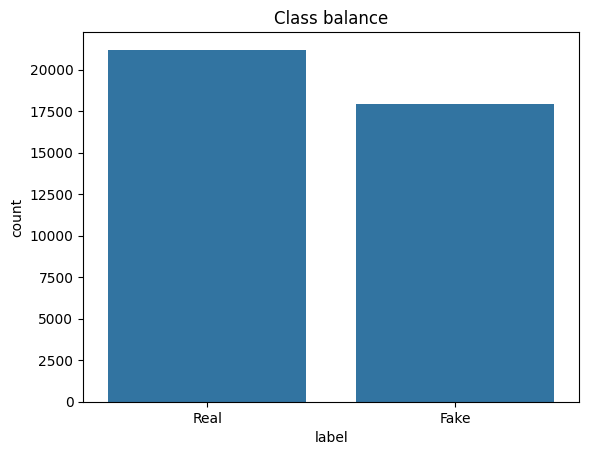

count    39105.000000
mean       410.476614
std        315.167468
min          2.000000
25%        220.000000
50%        378.000000
75%        521.000000
max       8148.000000
Name: text, dtype: float64


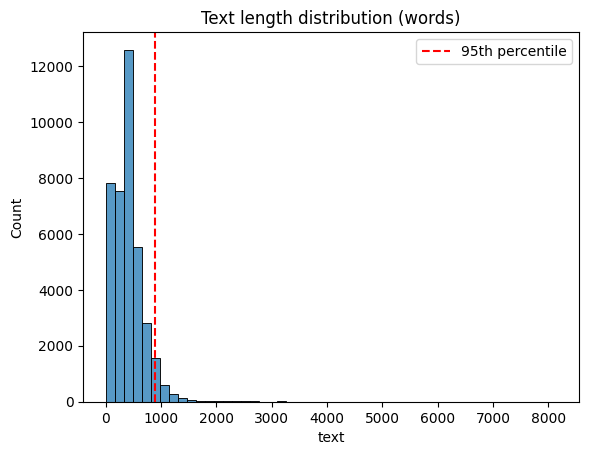

In [5]:
print("Label distribution:")
print(df['label'].value_counts(normalize=True).rename({0: 'Real', 1: 'Fake'}))

sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Real', 'Fake'])
plt.title('Class balance')
plt.show()

word_counts = df['text'].str.split().apply(len)
print(word_counts.describe())
sns.histplot(word_counts, bins=50)
plt.axvline(word_counts.quantile(0.95), color='red', linestyle='--', label='95th percentile')
plt.legend()
plt.title('Text length distribution (words)')
plt.show()

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)

max_words = 10000
max_len = int(word_counts.quantile(0.95))
print(f"Using max_len={max_len} (95th percentile of word counts)")

df.head()

Using max_len=890 (95th percentile of word counts)


,text,label,clean_text
0,Donald Trump Sends Out Embarrassing New Year’...,1,donald trump sends embarrassing new year’s eve...
1,Drunk Bragging Trump Staffer Started Russian ...,1,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,1,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,1,trump obsessed even obama’s name coded website...
4,Pope Francis Just Called Out Donald Trump Dur...,1,pope francis called donald trump christmas spe...


In [7]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=SEED, stratify=df['label']
)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)   # fit on TRAIN only

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=max_len, padding='post', truncating='post')

y_train = y_train.values
y_test = y_test.values

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Class weights to counter any imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Train shape: (31280, 890) Test shape: (7820, 890)
Class weights: {0: np.float64(0.922278570586154), 1: np.float64(1.0920262533165759)}


In [8]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                  initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                  initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = keras.ops.tanh(keras.ops.dot(x, self.W) + self.b)
        alpha = keras.ops.softmax(e, axis=1)
        output = x * alpha
        return keras.ops.sum(output, axis=1)


def build_bilstm_model(embedding_dim=128):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_attention_bilstm_model(embedding_dim=128):
    input_layer = Input(shape=(max_len,))
    x = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len)(input_layer)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Attention()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_attention_bilstm_model().summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 890)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 890, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 890, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │         1,018 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,388,155 (5.30 MB)

 Trainable params: 1,388,155 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
N_SPLITS = 5
EPOCHS_CV = 3
BATCH_SIZE = 64

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics = {'accuracy': [], 'f1': [], 'roc_auc': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    print(f"\n--- Fold {fold}/{N_SPLITS} ---")
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(enumerate(cw))

    fold_model = build_attention_bilstm_model()
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    fold_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_CV,
        batch_size=BATCH_SIZE,
        class_weight=cw_dict,
        callbacks=[early_stop],
        verbose=0
    )

    val_probs = fold_model.predict(X_val, verbose=0).ravel()
    val_preds = (val_probs > 0.5).astype(int)

    acc = accuracy_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds)
    auc = roc_auc_score(y_val, val_probs)

    fold_metrics['accuracy'].append(acc)
    fold_metrics['f1'].append(f1)
    fold_metrics['roc_auc'].append(auc)

    print(f"Fold {fold}: accuracy={acc:.4f}  f1={f1:.4f}  roc_auc={auc:.4f}")

print("\n=== Cross-validation summary (mean +/- std) ===")
for metric, values in fold_metrics.items():
    print(f"{metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}")


--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 1: accuracy=0.9947  f1=0.9942  roc_auc=0.9997

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 2: accuracy=0.9931  f1=0.9925  roc_auc=0.9991

--- Fold 3/5 ---


...

Fold 3: accuracy=0.9973  f1=0.9970  roc_auc=0.9999

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 4: accuracy=0.9966  f1=0.9963  roc_auc=0.9998

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 5: accuracy=0.9968  f1=0.9965  roc_auc=0.9999

=== Cross-validation summary (mean +/- std) ===
accuracy: 0.9957 +/- 0.0016
f1: 0.9953 +/- 0.0017
roc_auc: 0.9997 +/- 0.0003


In [10]:
attention_model = build_attention_bilstm_model()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6)
]

history = attention_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 942s 2s/step - accuracy: 0.9286 - loss: 0.1604 - val_accuracy: 0.9904 - val_loss: 0.0542 - learning_rate: 0.0010
Epoch 2/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 932s 2s/step - accuracy: 0.9918 - loss: 0.0295 - val_accuracy: 0.9971 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 3/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 948s 2s/step - accuracy: 0.9991 - loss: 0.0048 - val_accuracy: 0.9962 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 4/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 983s 2s/step - accuracy: 0.9970 - loss: 0.0101 - val_accuracy: 0.9981 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 5/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 948s 2s/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9984 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 6/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.9999 - loss: 6.0127e-04 - val_accuracy: 0.9984 - val_loss: 0.0057 - learning_rate: 5.0000e-04
Epoch 7/15
440/440 ━━━━━━━━━━━━━━━━━━━━ 932s 2s/step - accuracy: 1

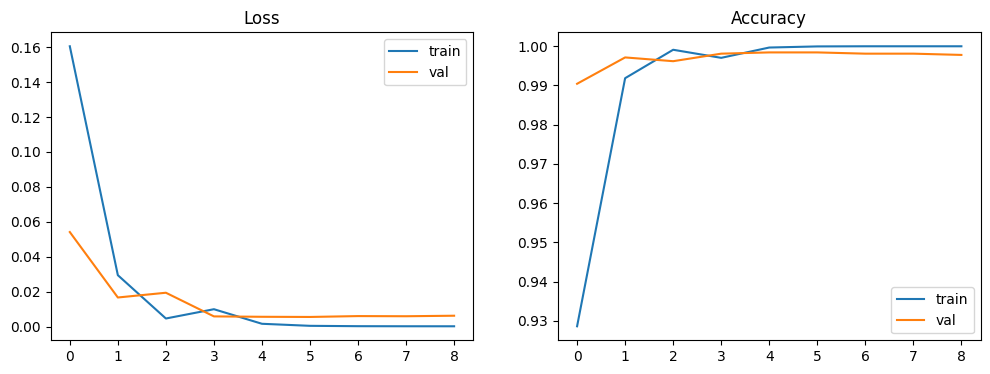

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()

245/245 ━━━━━━━━━━━━━━━━━━━━ 61s 246ms/step
Test Loss: 0.0046
Test Accuracy: 0.9988
Test ROC-AUC: 0.9999

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4239
        Fake       1.00      1.00      1.00      3581

    accuracy                           1.00      7820
   macro avg       1.00      1.00      1.00      7820
weighted avg       1.00      1.00      1.00      7820



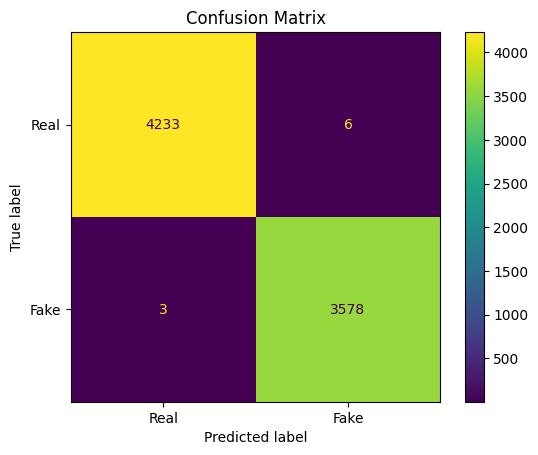

In [12]:
test_probs = attention_model.predict(X_test).ravel()
test_preds = (test_probs > 0.5).astype(int)

test_loss, test_acc = attention_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['Real', 'Fake']))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake']).plot()
plt.title('Confusion Matrix')
plt.show()

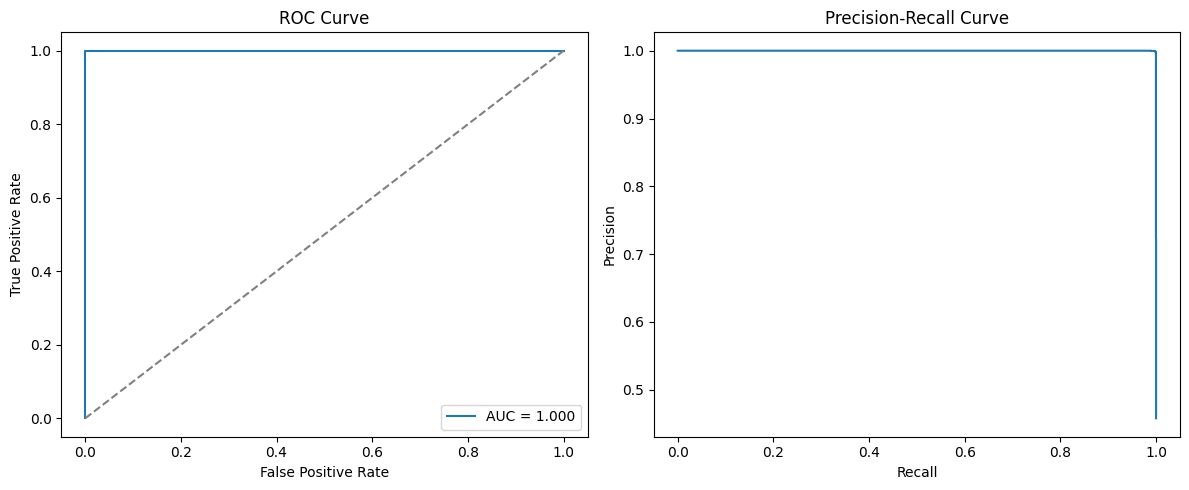

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, test_probs)
axes[1].plot(recall, precision)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

In [14]:
def predict_fake_news(text, model, tokenizer, max_len):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = float(model.predict(padded, verbose=0)[0][0])
    label = "Fake News" if prob > 0.5 else "Real News"
    return label, prob

example_news = "This is an example of a news article. It talks about recent events."
label, prob = predict_fake_news(example_news, attention_model, tokenizer, max_len)
print(f"Prediction: {label}  (P(fake)={prob:.4f})")

Prediction: Fake News  (P(fake)=0.9997)


In [15]:
import pickle

attention_model.save('attention_bilstm_fake_news.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('config.pkl', 'wb') as f:
    pickle.dump({'max_len': max_len, 'max_words': max_words}, f)

print("Saved: attention_bilstm_fake_news.keras, tokenizer.pkl, config.pkl")

Saved: attention_bilstm_fake_news.keras, tokenizer.pkl, config.pkl
